# Import Required Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
train = pd.read_csv("train.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")
test = pd.read_csv("test.csv")

train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [37]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [38]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [39]:
test.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


In [40]:
# Convert Date Columns

features['Date'] = pd.to_datetime(features['Date'])
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])


In [41]:
# Merge Datasets

df = pd.merge(train, features, on=['Store', 'Date', 'IsHoliday'], how='left')
df = pd.merge(df, stores, on='Store', how='left')


In [42]:
test_df = pd.merge(test, features, on=['Store','Date','IsHoliday'], how='left')
test_df = pd.merge(test_df, stores, on='Store', how='left')

In [43]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


The train dataset containing historical sales was merged with features dataset (economic indicators and holiday info) and stores dataset (store type and size) using left joins on Store and Date. This ensures all relevant variables are available for forecasting weekly sales.

# Task 1: Data Cleaning and Pre-processing

In [96]:
# Handle Missing Values

# Check missing values
df.isnull().sum()

# Handle missing values
# print(df = df.dropna())  # or can use fillna()

Store             0
Dept              0
Date              0
Weekly_Sales      0
IsHoliday         0
Temperature       0
Fuel_Price        0
MarkDown1         0
MarkDown2         0
MarkDown3         0
MarkDown4         0
MarkDown5         0
CPI               0
Unemployment      0
Type              0
Size              0
Year              0
Month             0
Week              0
Day               0
Total_Markdown    0
dtype: int64

In [45]:
# Markdown columns → fill missing with 0 (no promotion)
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
for col in markdown_cols:
    if col in df.columns:
        df[col].fillna(0, inplace=True)

# CPI & Unemployment → fill with mean
df['CPI'].fillna(df['CPI'].mean(), inplace=True)
df['Unemployment'].fillna(df['Unemployment'].mean(), inplace=True)

df.isnull().sum()



Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

In [46]:
print("Duplicates:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

Duplicates: 0


In [47]:
# Transform Variables (Data Types)
# Convert categorical variables
df['Type'] = df['Type'].astype('category')
df['IsHoliday'] = df['IsHoliday'].astype('bool')

# create numeric features for analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Day'] = df['Date'].dt.day

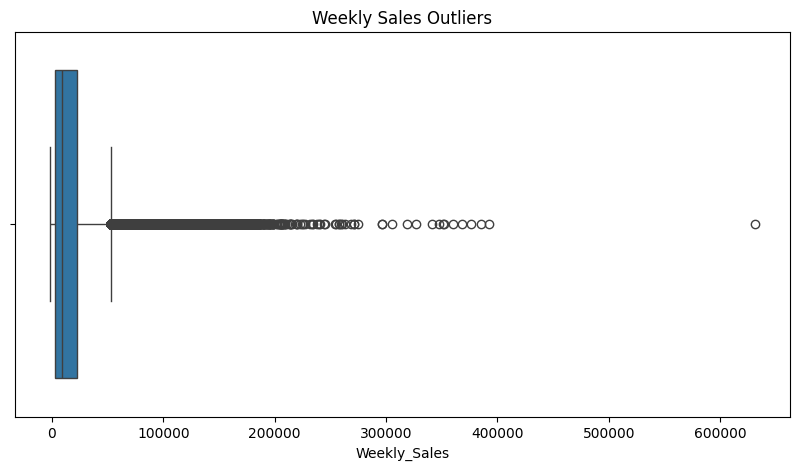

Shape after outlier removal: (88995, 20)


In [48]:
# Detect and Handle Outliers
# Boxplot for Weekly_Sales
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Weekly_Sales'])
plt.title("Weekly Sales Outliers")
plt.show()

# Remove outliers using IQR method
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Weekly_Sales'] >= lower) & (df['Weekly_Sales'] <= upper)]

# Check final shape
print("Shape after outlier removal:", df.shape)

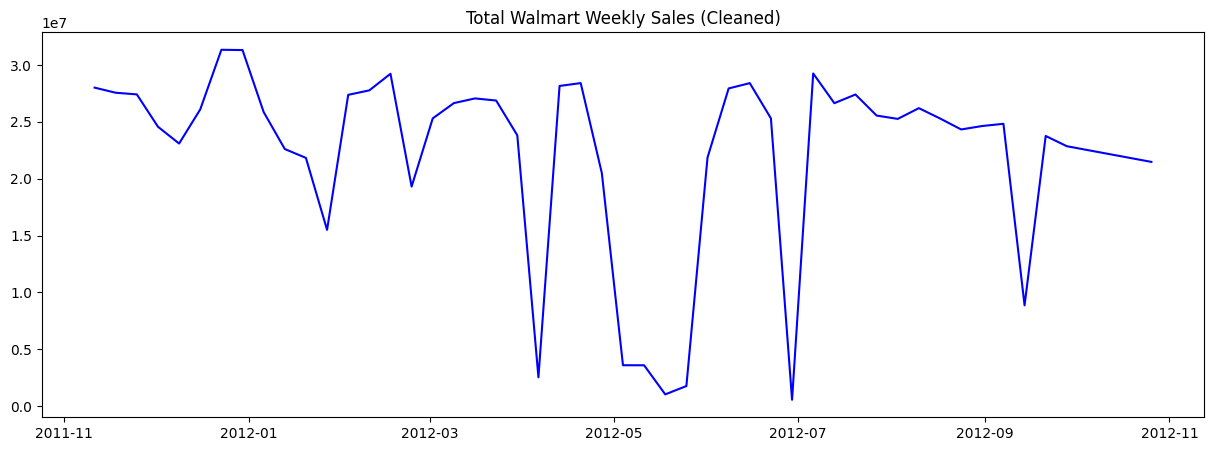

In [49]:
# Feature Engineering
# Combine Markdown columns into a total promotion feature
df['Total_Markdown'] = df[markdown_cols].sum(axis=1)

# Optional: aggregate sales for total Walmart weekly sales
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
weekly_sales.set_index('Date', inplace=True)

# Quick plot to check
plt.figure(figsize=(15,5))
plt.plot(weekly_sales['Weekly_Sales'], color='blue')
plt.title("Total Walmart Weekly Sales (Cleaned)")
plt.show()

In [50]:
# Export merged dataset to CSV (After Cleaned)
df.to_csv("walmart_merged.csv", index=False, encoding='utf-8-sig')

print("Dataset saved successfully!")
print(f"Shape: {df.shape}")

Dataset saved successfully!
Shape: (88995, 21)


In [51]:
test_df.to_csv("walmart_merged_test.csv", index=False)

# Task 2: Exploratory Data Analysis (EDA)

In [52]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from scipy import stats

In [53]:
# Descriptive Statistics
df.describe()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Year,Month,Week,Day,Total_Markdown
count,88995.000000,88995.000000,88995,88995.000000,88995.000000,88995.000000,88995.000000,88995.000000,88995.000000,88995.000000,88995.000000,88995.000000,88995.000000,88995.000000,88995.000000,88995.000000,88995.0,88995.000000,88995.000000
mean,20.400933,42.853711,2012-04-17 02:43:24.523849728,12009.754836,57.294222,3.620920,8756.246945,3661.934211,1705.808533,3969.637441,5214.188894,174.780991,7.434550,152910.798753,2011.810484,6.306534,25.442486,16.019821,23307.816024
min,1.000000,1.000000,2011-11-11 00:00:00,-1699.000000,7.460000,3.031000,32.500000,-265.760000,-29.100000,0.460000,170.640000,129.816710,4.077000,34875.000000,2011.000000,1.000000,1.0,1.000000,567.350000
25%,11.000000,19.000000,2012-01-20 00:00:00,2443.135000,42.740000,3.415000,3548.090000,46.130000,5.170000,597.550000,2312.380000,136.959839,6.392000,118221.000000,2012.000000,3.000000,11.0,9.000000,9837.800000
50%,20.000000,35.000000,2012-03-30 00:00:00,7333.100000,57.950000,3.630000,6233.580000,191.820000,27.820000,1696.730000,3796.720000,189.194056,7.348000,155078.000000,2012.000000,7.000000,27.0,16.000000,16563.980000
75%,29.000000,67.000000,2012-07-20 00:00:00,17844.955000,72.620000,3.820000,10283.490000,2551.320000,118.370000,4025.820000,6133.900000,219.355063,8.304000,203742.000000,2012.000000,9.000000,38.0,23.000000,28035.120000
max,45.000000,99.000000,2012-10-26 00:00:00,52697.440000,95.910000,4.301000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.036936,12.890000,219622.000000,2012.000000,12.000000,52.0,31.000000,160510.610000
std,12.030276,29.185006,NaN,12541.683118,18.301622,0.279935,9187.470004,9925.651871,10536.777719,7100.398931,6422.159535,39.601892,1.713784,51585.708467,0.391920,3.581339,15.73839,8.662596,21381.396691


In [54]:
# Grouped Statistics
# Average sales by store type
df.groupby('Type')['Weekly_Sales'].mean().sort_values(ascending=False)

# Average sales by holiday vs non-holiday
df.groupby('IsHoliday')['Weekly_Sales'].mean()

C:\Users\Dureksha Arangala\AppData\Local\Temp\ipykernel_11076\974671129.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Type')['Weekly_Sales'].mean().sort_values(ascending=False)


IsHoliday
False    11988.160993
True     12198.693872
Name: Weekly_Sales, dtype: float64

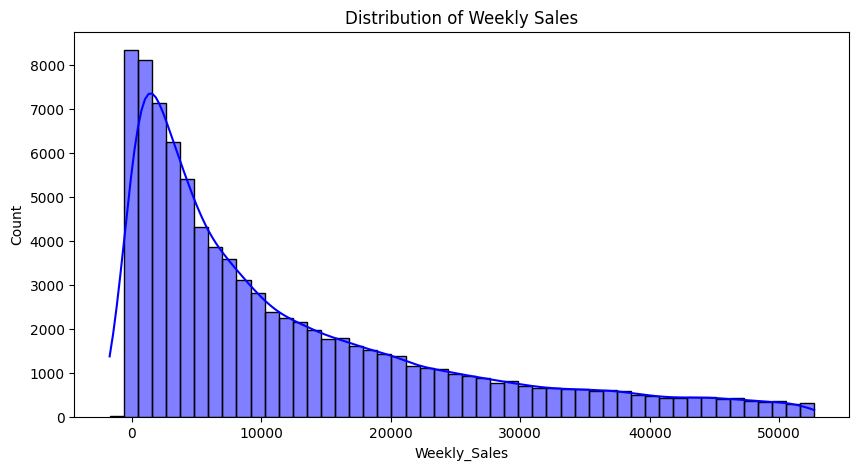

In [55]:
# Visualizations
# Distribution of Weekly Sales
plt.figure(figsize=(10,5))
sns.histplot(df['Weekly_Sales'], bins=50, kde=True, color='blue')
plt.title("Distribution of Weekly Sales")
plt.show()

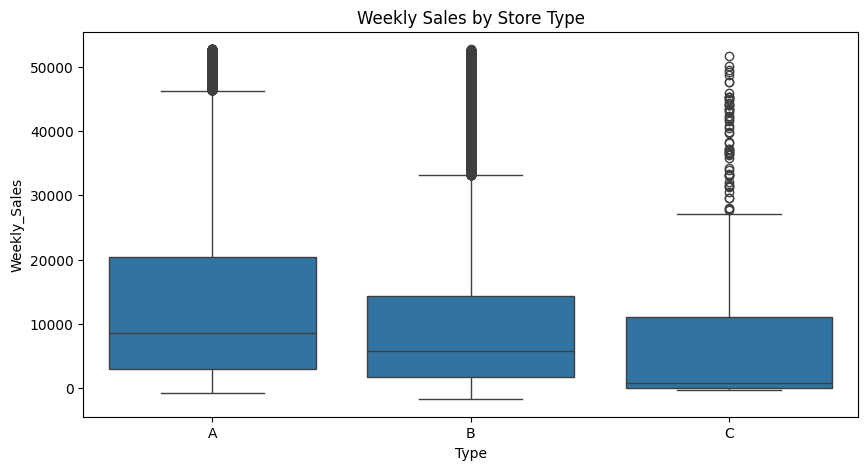

In [56]:
# Boxplots to Identify Outliers / Compare Categories
plt.figure(figsize=(10,5))
sns.boxplot(x='Type', y='Weekly_Sales', data=df)
plt.title("Weekly Sales by Store Type")
plt.show()

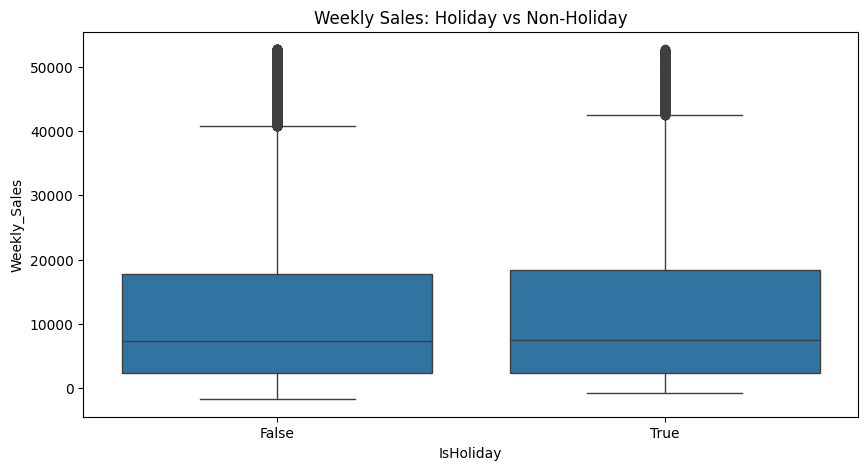

In [57]:
plt.figure(figsize=(10,5))
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df)
plt.title("Weekly Sales: Holiday vs Non-Holiday")
plt.show()

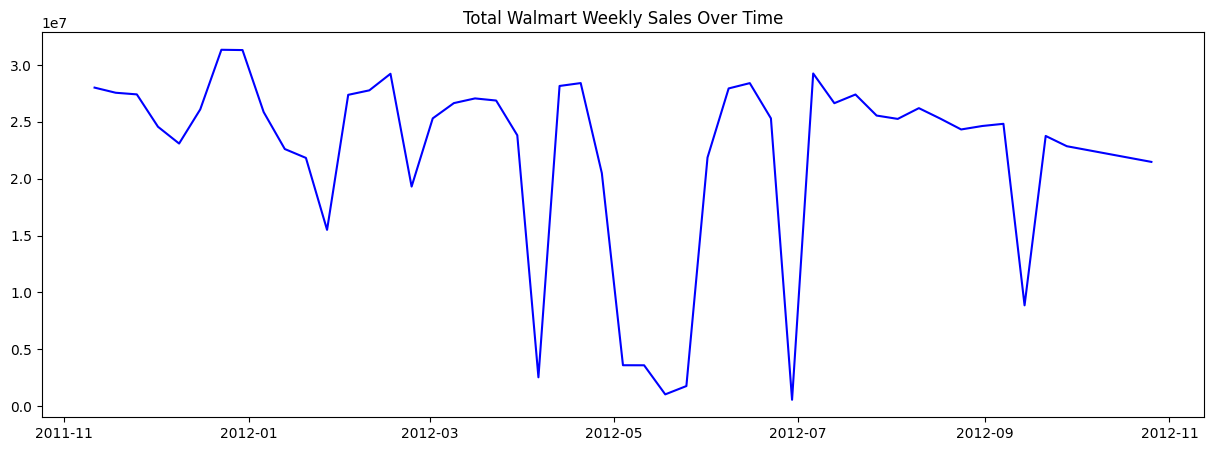

In [58]:
# Trend Over Time
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
weekly_sales.set_index('Date', inplace=True)

plt.figure(figsize=(15,5))
plt.plot(weekly_sales['Weekly_Sales'], color='blue')
plt.title("Total Walmart Weekly Sales Over Time")
plt.show()

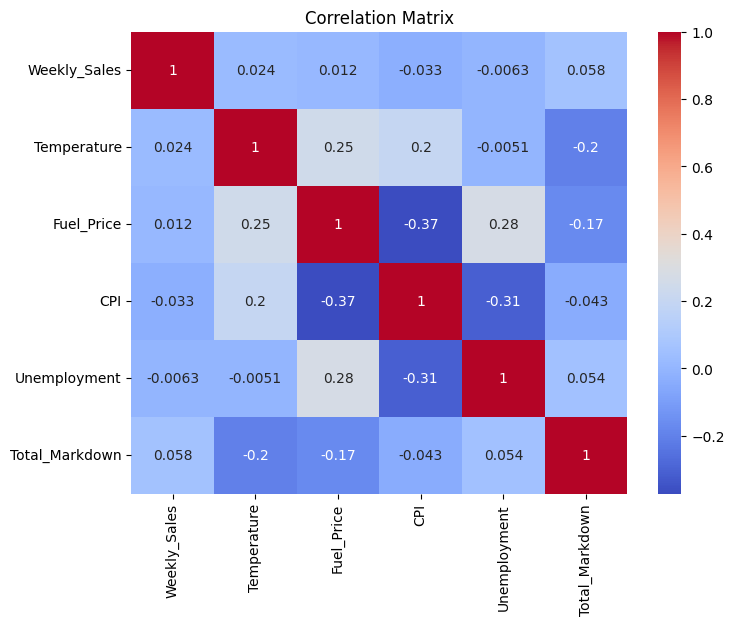

In [59]:
# Correlation Heatmap
numeric_cols = ['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment','Total_Markdown']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

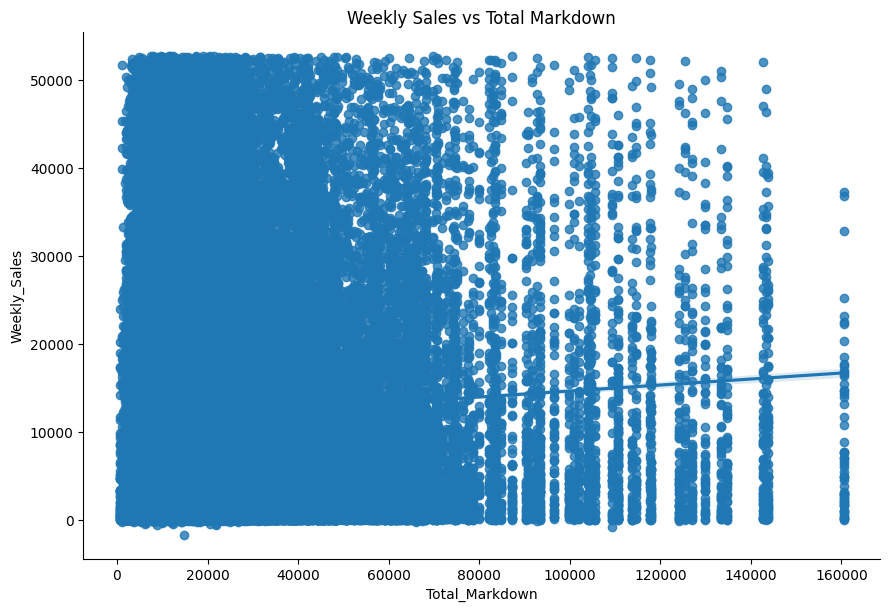

In [60]:
# Regression Plots
sns.lmplot(x='Total_Markdown', y='Weekly_Sales', data=df, height=6, aspect=1.5)
plt.title("Weekly Sales vs Total Markdown")
plt.show()

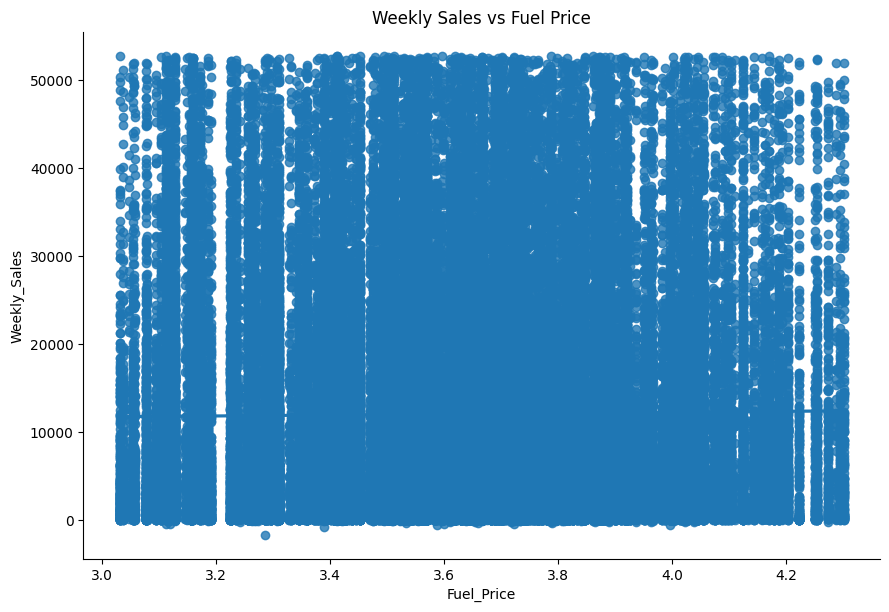

In [61]:
sns.lmplot(x='Fuel_Price', y='Weekly_Sales', data=df, height=6, aspect=1.5)
plt.title("Weekly Sales vs Fuel Price")
plt.show()

In [62]:
# Inferential Statistics (Hypothesis Testing)
# Holiday Effect on Sales (T-test)

holiday_sales = df[df['IsHoliday']==True]['Weekly_Sales']
non_holiday_sales = df[df['IsHoliday']==False]['Weekly_Sales']

t_stat, p_val = stats.ttest_ind(holiday_sales, non_holiday_sales)
print("T-statistic:", t_stat)
print("p-value:", p_val)

T-statistic: 1.5193435842658
p-value: 0.12867958694675924


In [63]:
# Correlation Significance
corr, p = stats.pearsonr(df['Total_Markdown'], df['Weekly_Sales'])
print("Correlation between Total Markdown and Weekly Sales:", corr)
print("p-value:", p)

Correlation between Total Markdown and Weekly Sales: 0.05806548079736523
p-value: 2.494920878564712e-67


In [64]:
# Sampling estimation example
sample = df['Weekly_Sales'].sample(1000)

sample_mean = sample.mean()
population_mean = df['Weekly_Sales'].mean()

print("Sample Mean:", sample_mean)
print("Population Mean:", population_mean)

Sample Mean: 11488.43574
Population Mean: 12009.754836226753


# Task 3: Model Building

In [65]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

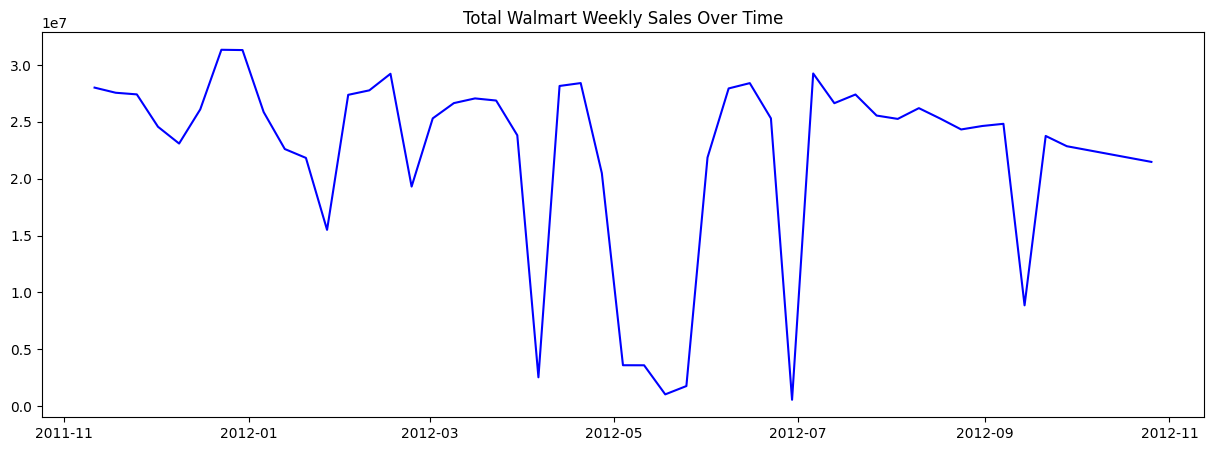

In [66]:
# Prepare Time Series Data
# Aggregate total weekly sales
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
weekly_sales.set_index('Date', inplace=True)

# Plot to check trend and seasonality
plt.figure(figsize=(15,5))
plt.plot(weekly_sales['Weekly_Sales'], color='blue')
plt.title("Total Walmart Weekly Sales Over Time")
plt.show()

In [67]:
# Split Data into Train and Test
train_size = int(len(weekly_sales) * 0.8)
train_ts = weekly_sales.iloc[:train_size]
test_ts = weekly_sales.iloc[train_size:]

print(f"Train size: {train_ts.shape}, Test size: {test_ts.shape}")

Train size: (38, 1), Test size: (10, 1)


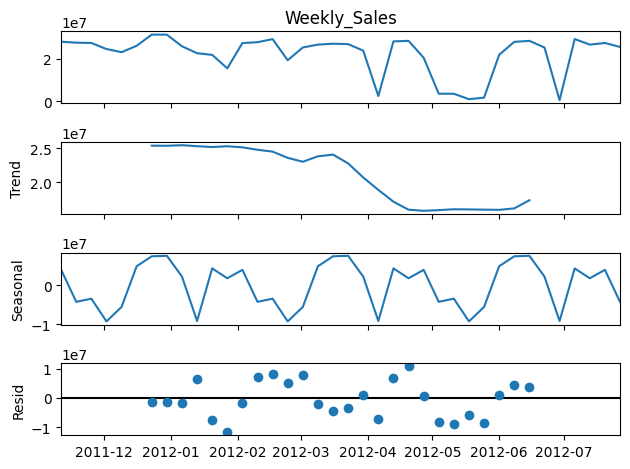

In [69]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(train_ts['Weekly_Sales'], model='additive', period=12)

decomposition.plot()
plt.show()

In [70]:
# Build SARIMA Model
# SARIMA parameters: (p,d,q) x (P,D,Q,s)
# p,d,q = 1,1,1 and seasonal P,D,Q = 1,1,1 with s=52
model = SARIMAX(train_ts['Weekly_Sales'], order=(1,1,1), seasonal_order=(1,1,1,52))
model_fit = model.fit(disp=False)

print(model_fit.summary())

C:\Users\Dureksha Arangala\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Dureksha Arangala\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Dureksha Arangala\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\Dureksha Arangala\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations

                                     SARIMAX Results                                      
Dep. Variable:                       Weekly_Sales   No. Observations:                   38
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                   0.000
Date:                            Fri, 06 Mar 2026   AIC                             10.000
Time:                                    21:43:32   BIC                                nan
Sample:                                11-11-2011   HQIC                               nan
                                     - 07-27-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1               0         -0        nan        nan           0           0
ma.L1               0         -0   

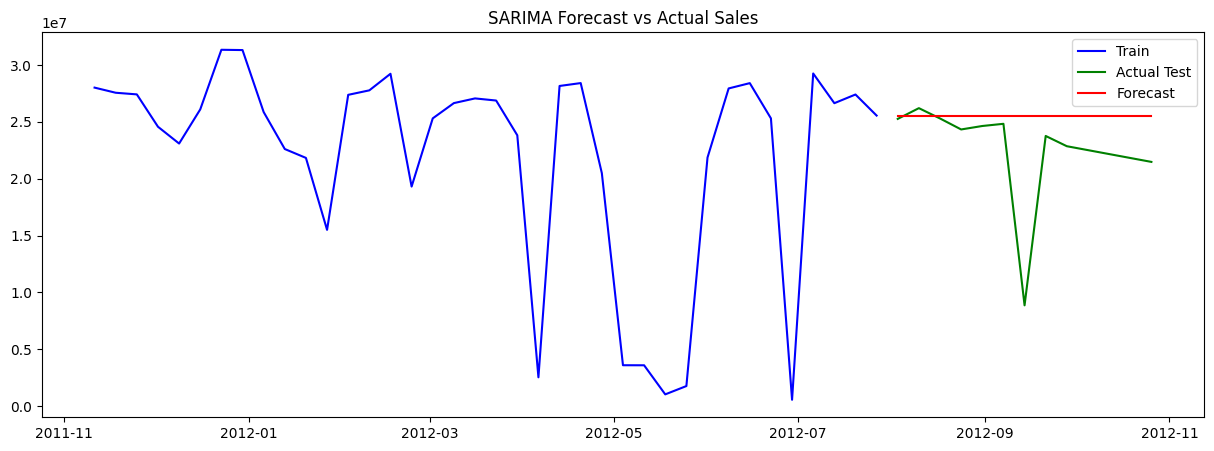

In [71]:
# Forecast on Test Set
# Forecast for the test period
forecast = model_fit.forecast(len(test_ts))

# Compare forecast vs actual
plt.figure(figsize=(15,5))
plt.plot(train_ts.index, train_ts['Weekly_Sales'], label='Train', color='blue')
plt.plot(test_ts.index, test_ts['Weekly_Sales'], label='Actual Test', color='green')
plt.plot(test_ts.index, forecast, label='Forecast', color='red')
plt.title("SARIMA Forecast vs Actual Sales")
plt.legend()
plt.show()

In [72]:
# Evaluate Model Performance
rmse = math.sqrt(mean_squared_error(test_ts['Weekly_Sales'], forecast))
mae = mean_absolute_error(test_ts['Weekly_Sales'], forecast)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Root Mean Squared Error (RMSE): 5561008.77
Mean Absolute Error (MAE): 2933001.10


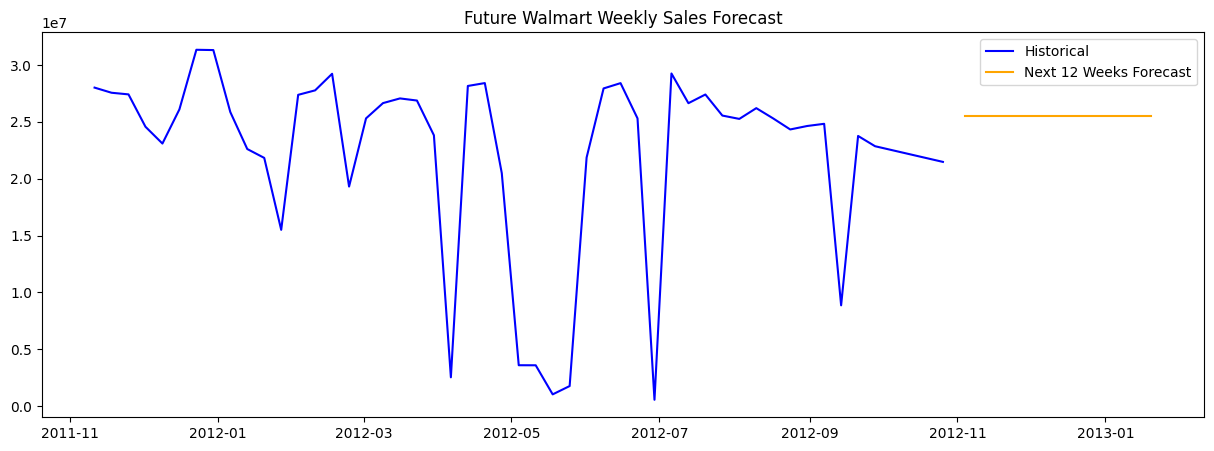

In [73]:
# Forecast Future Weeks
# Forecast next 12 weeks (example)
future_forecast = model_fit.forecast(steps=12)
future_dates = pd.date_range(start=weekly_sales.index[-1] + pd.Timedelta(weeks=1), periods=12, freq='W')

plt.figure(figsize=(15,5))
plt.plot(weekly_sales.index, weekly_sales['Weekly_Sales'], label='Historical', color='blue')
plt.plot(future_dates, future_forecast, label='Next 12 Weeks Forecast', color='orange')
plt.title("Future Walmart Weekly Sales Forecast")
plt.legend()
plt.show()

# Task 4: Data Visualization

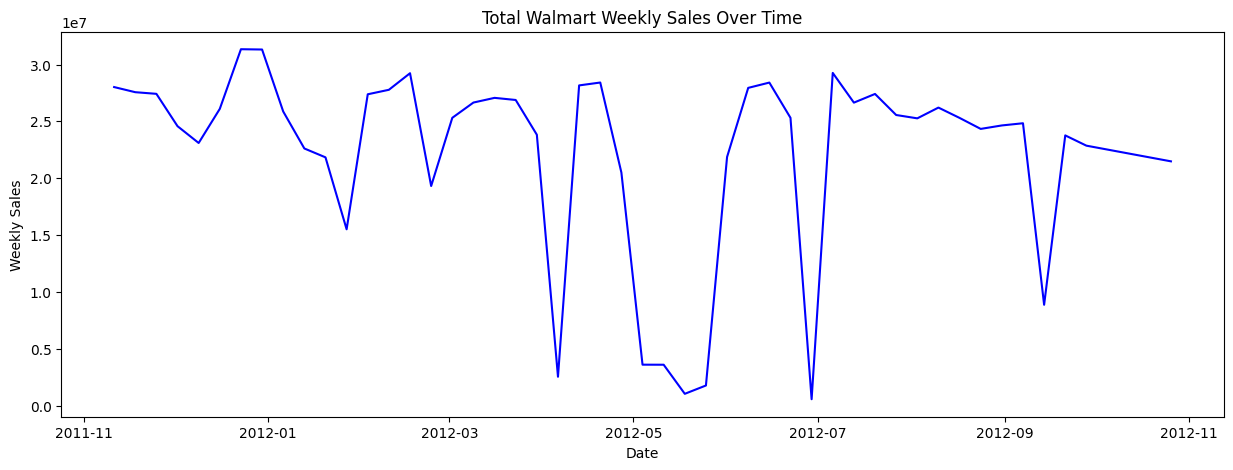

In [74]:
# Time Series Visualization
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
weekly_sales.set_index('Date', inplace=True)

plt.figure(figsize=(15,5))
plt.plot(weekly_sales['Weekly_Sales'], color='blue')
plt.title("Total Walmart Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()

C:\Users\Dureksha Arangala\AppData\Local\Temp\ipykernel_11076\796380315.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Weekly_Sales', data=monthly_sales, palette="viridis")


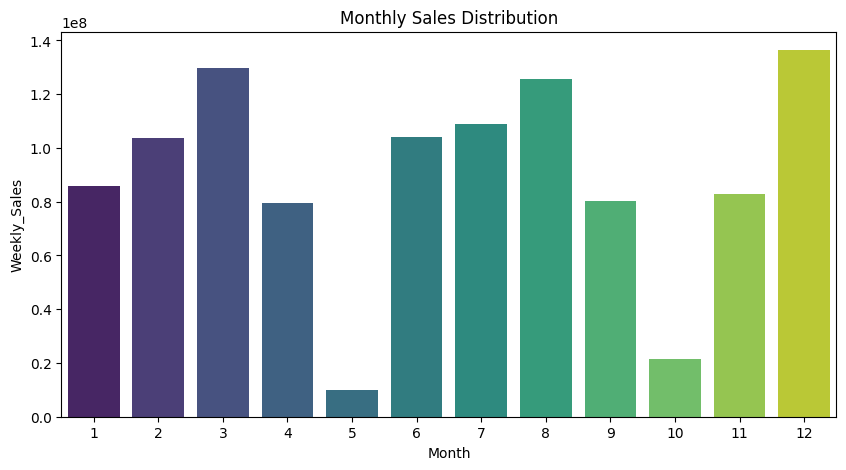

In [75]:
# Seasonal Patterns
# Aggregate by month to visualize seasonality
df['Month'] = df['Date'].dt.month
monthly_sales = df.groupby('Month')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(x='Month', y='Weekly_Sales', data=monthly_sales, palette="viridis")
plt.title("Monthly Sales Distribution")
plt.show()

C:\Users\Dureksha Arangala\AppData\Local\Temp\ipykernel_11076\430732176.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_sales = df.groupby('Type')['Weekly_Sales'].sum().reset_index()
C:\Users\Dureksha Arangala\AppData\Local\Temp\ipykernel_11076\430732176.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Type', y='Weekly_Sales', data=type_sales, palette="pastel")


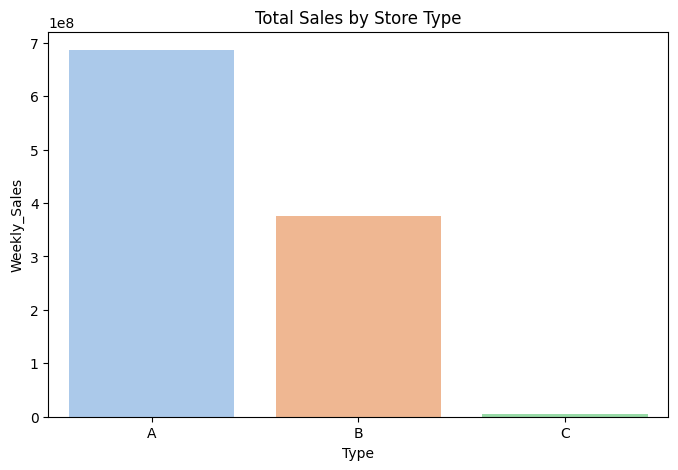

In [76]:
# Sales by Store Type
type_sales = df.groupby('Type')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Type', y='Weekly_Sales', data=type_sales, palette="pastel")
plt.title("Total Sales by Store Type")
plt.show()

C:\Users\Dureksha Arangala\AppData\Local\Temp\ipykernel_11076\2142898629.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df, palette="Set2")


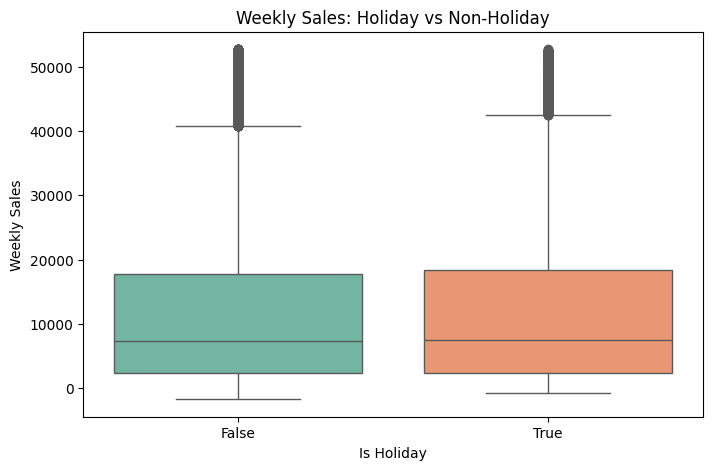

In [77]:
# Boxplot – Holiday vs Non-Holiday Sales
plt.figure(figsize=(8,5))
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df, palette="Set2")
plt.title("Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Is Holiday")
plt.ylabel("Weekly Sales")
plt.show()

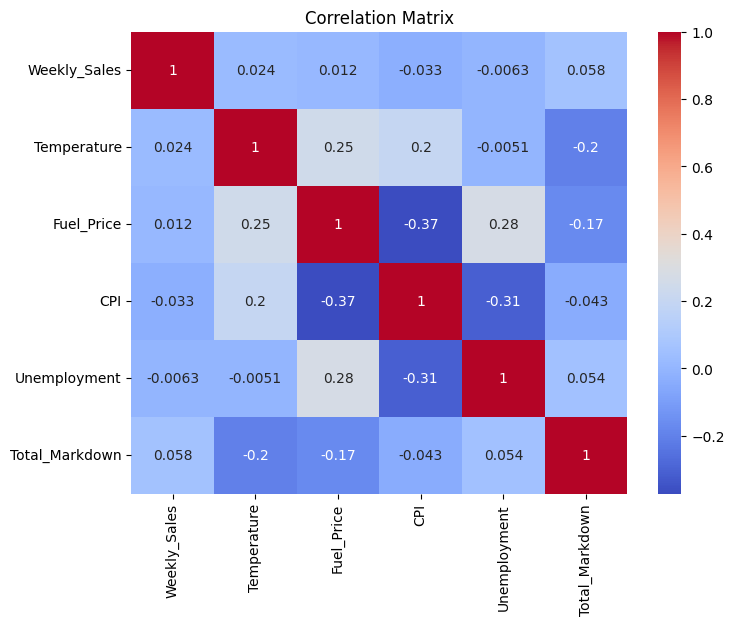

In [78]:
# Correlation Heatmap
numeric_cols = ['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment','Total_Markdown']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

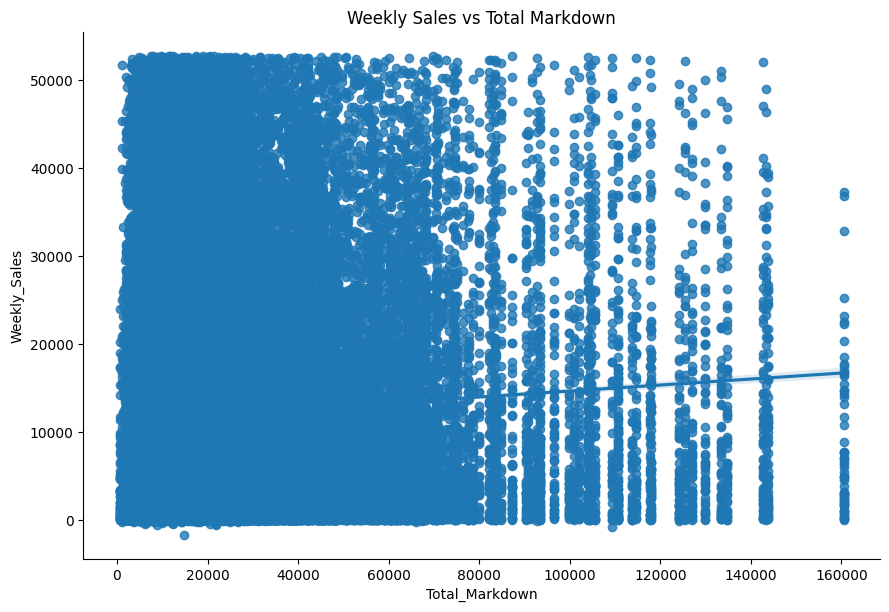

In [81]:
# Regression Plots (Weekly Sales vs Markdown/Price)
sns.lmplot(x='Total_Markdown', y='Weekly_Sales', data=df, height=6, aspect=1.5)
plt.title("Weekly Sales vs Total Markdown")
plt.show()

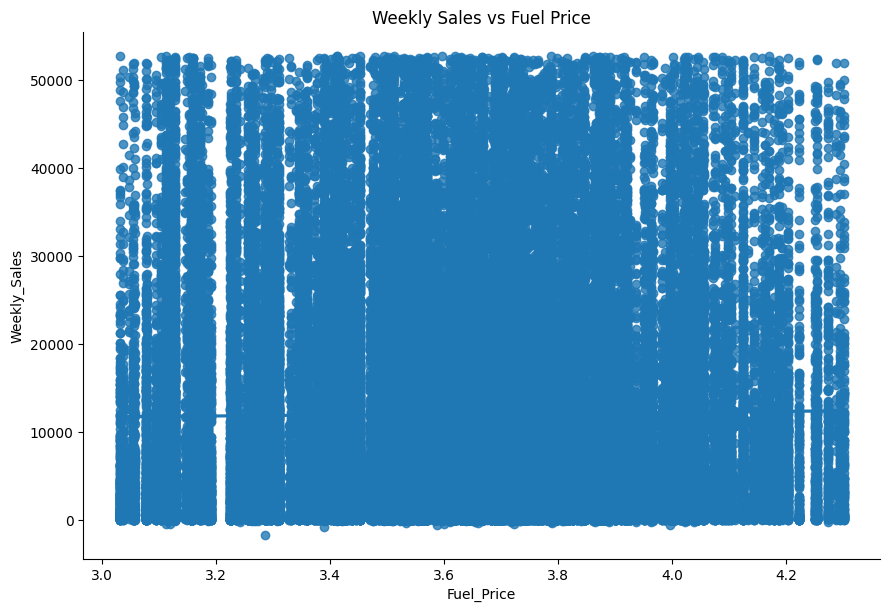

In [80]:
sns.lmplot(x='Fuel_Price', y='Weekly_Sales', data=df, height=6, aspect=1.5)
plt.title("Weekly Sales vs Fuel Price")
plt.show()

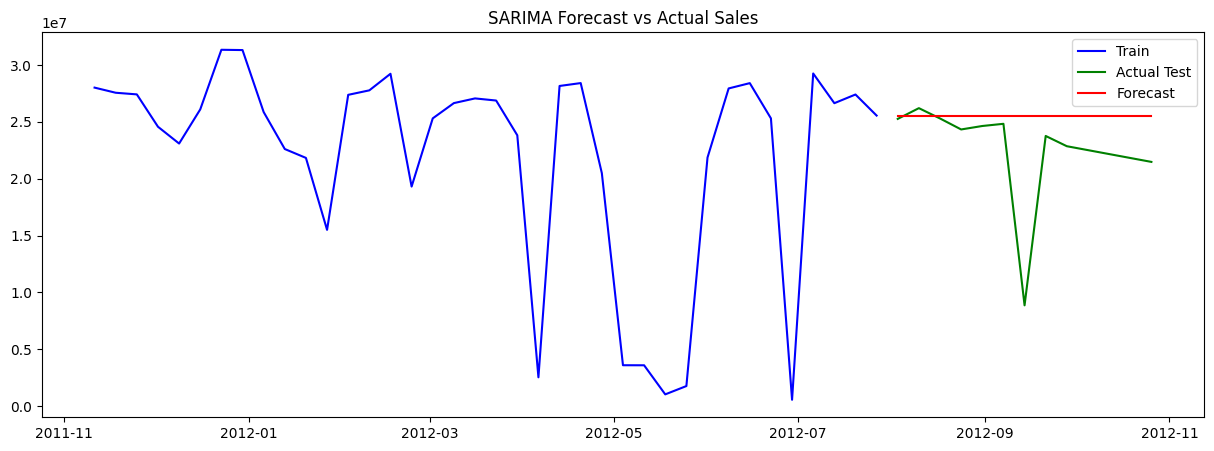

In [82]:
# SARIMA Forecast Visualization
plt.figure(figsize=(15,5))
plt.plot(train_ts.index, train_ts['Weekly_Sales'], label='Train', color='blue')
plt.plot(test_ts.index, test_ts['Weekly_Sales'], label='Actual Test', color='green')
plt.plot(test_ts.index, forecast, label='Forecast', color='red')
plt.title("SARIMA Forecast vs Actual Sales")
plt.legend()
plt.show()

# Task 5: Model Evaluation

In [83]:
# Forecasted vs Actual Values
# train_ts, test_ts, forecast from SARIMA model
# Optional: display head of forecast vs actual
comparison = pd.DataFrame({'Actual': test_ts['Weekly_Sales'], 'Forecast': forecast})
comparison.head(10)


,Actual,Forecast
2012-08-03,25264376.15,25558310.57
2012-08-10,26210660.47,25558310.57
2012-08-17,25302190.64,25558310.57
2012-08-24,24335924.75,25558310.57
2012-08-31,24640265.42,25558310.57
2012-09-07,24832671.15,25558310.57
2012-09-14,8864004.91,25558310.57
2012-09-21,23764054.81,25558310.57
2012-09-28,22861479.87,25558310.57
2012-10-05,NaN,25558310.57


In [84]:
# Root Mean Squared Error (RMSE)
rmse = math.sqrt(mean_squared_error(test_ts['Weekly_Sales'], forecast))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Root Mean Squared Error (RMSE): 5561008.77


Interpretation: RMSE measures the average magnitude of errors. Lower is better.

In [85]:
# Mean Absolute Error (MAE)
mae = mean_absolute_error(test_ts['Weekly_Sales'], forecast)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Error (MAE): 2933001.10


Interpretation: MAE is the average absolute difference between forecast and actual values. Easy to explain in business reports.

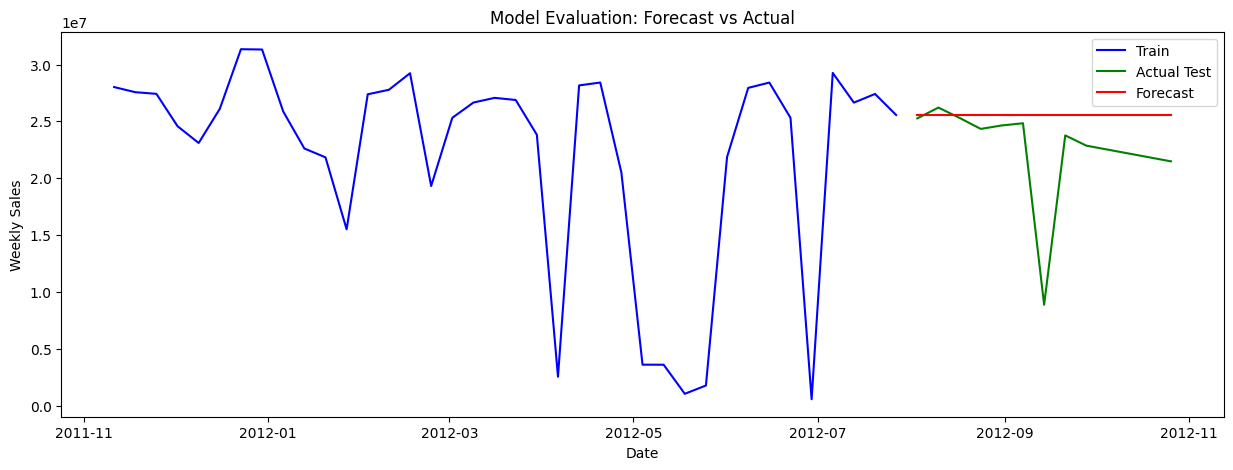

In [86]:
# Visualize Forecast Accuracy
plt.figure(figsize=(15,5))
plt.plot(train_ts.index, train_ts['Weekly_Sales'], label='Train', color='blue')
plt.plot(test_ts.index, test_ts['Weekly_Sales'], label='Actual Test', color='green')
plt.plot(test_ts.index, forecast, label='Forecast', color='red')
plt.title("Model Evaluation: Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.show()

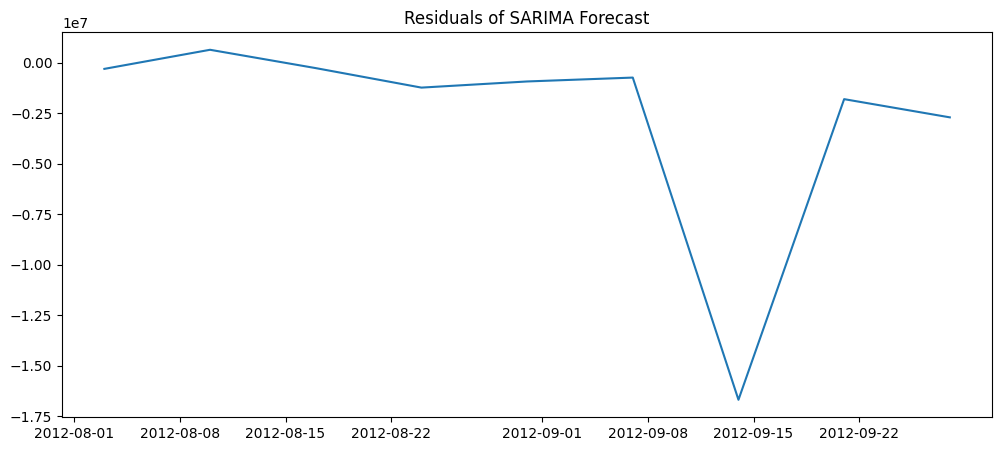

In [87]:
# Residual Analysis
residuals = test_ts['Weekly_Sales'] - forecast

plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title("Residuals of SARIMA Forecast")
plt.show()

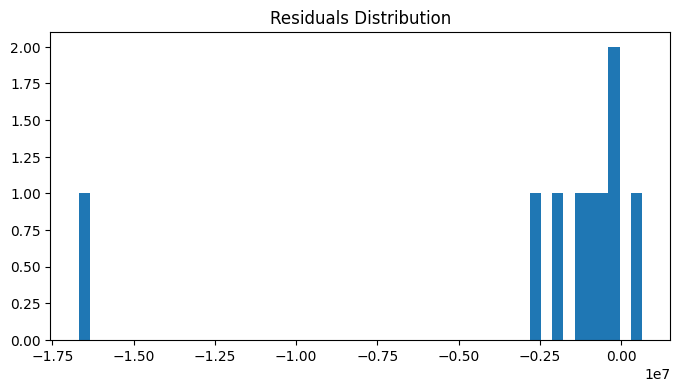

In [88]:
# Histogram
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=50)
plt.title("Residuals Distribution")
plt.show()

Interpretation: Residuals should be randomly distributed around 0 → indicates good model fit.

In [89]:
from sklearn.metrics import r2_score

# R2 Score
r2 = r2_score(test_ts['Weekly_Sales'], forecast)

# MAPE
mape = np.mean(np.abs((test_ts['Weekly_Sales'] - forecast) / test_ts['Weekly_Sales'])) * 100

print("R2 Score:", r2)
print("MAPE:", mape)

R2 Score: -0.34044055300621756
MAPE: 24.89114423391526
